In [82]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
import shap
from sklearn.inspection import PartialDependenceDisplay

from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler

In [85]:
stu_df = pd.read_table('StudentPerformanceFactors.csv', sep=',')

In [86]:
stu_df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


# Modeling

## Simple Linear / OLS (Ordinary Least Squares) Model

Simple way to see which features have a significant p-value, what the $R^{2}$ is for a full model with all variables, and to find the association of each feature on `Exam_Score`, either positive or negative.

In [87]:
# Clean df by dropping NA rows
df_clean = stu_df.dropna()

# Our target feature is "Exam_Score"
target = 'Exam_Score'

# Drop target to get all features
X_raw = df_clean.drop(columns=[target]) 
y = df_clean[target]

# Handle categorical data -> One-Hot Encoding
X = pd.get_dummies(X_raw, drop_first=True).astype(float)

# Add an intercept
X = sm.add_constant(X)

# Fit OLS model
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     609.8
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:28:38   Log-Likelihood:                -13675.
No. Observations:                6378   AIC:                         2.741e+04
Df Residuals:                    6350   BIC:                         2.759e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

## Decision Tree Model

Shows threshold values for the features, i.e., getting at least 6 hours of sleep matters more than the difference between 8 and 9 hours.

Top Features Leading to High Scores
Attendance                               0.674972
Hours_Studied                            0.325028
const                                    0.000000
Family_Income_Low                        0.000000
Distance_from_Home_Near                  0.000000
Distance_from_Home_Moderate              0.000000
Parental_Education_Level_Postgraduate    0.000000
Parental_Education_Level_High School     0.000000
Learning_Disabilities_Yes                0.000000
Peer_Influence_Positive                  0.000000
dtype: float64


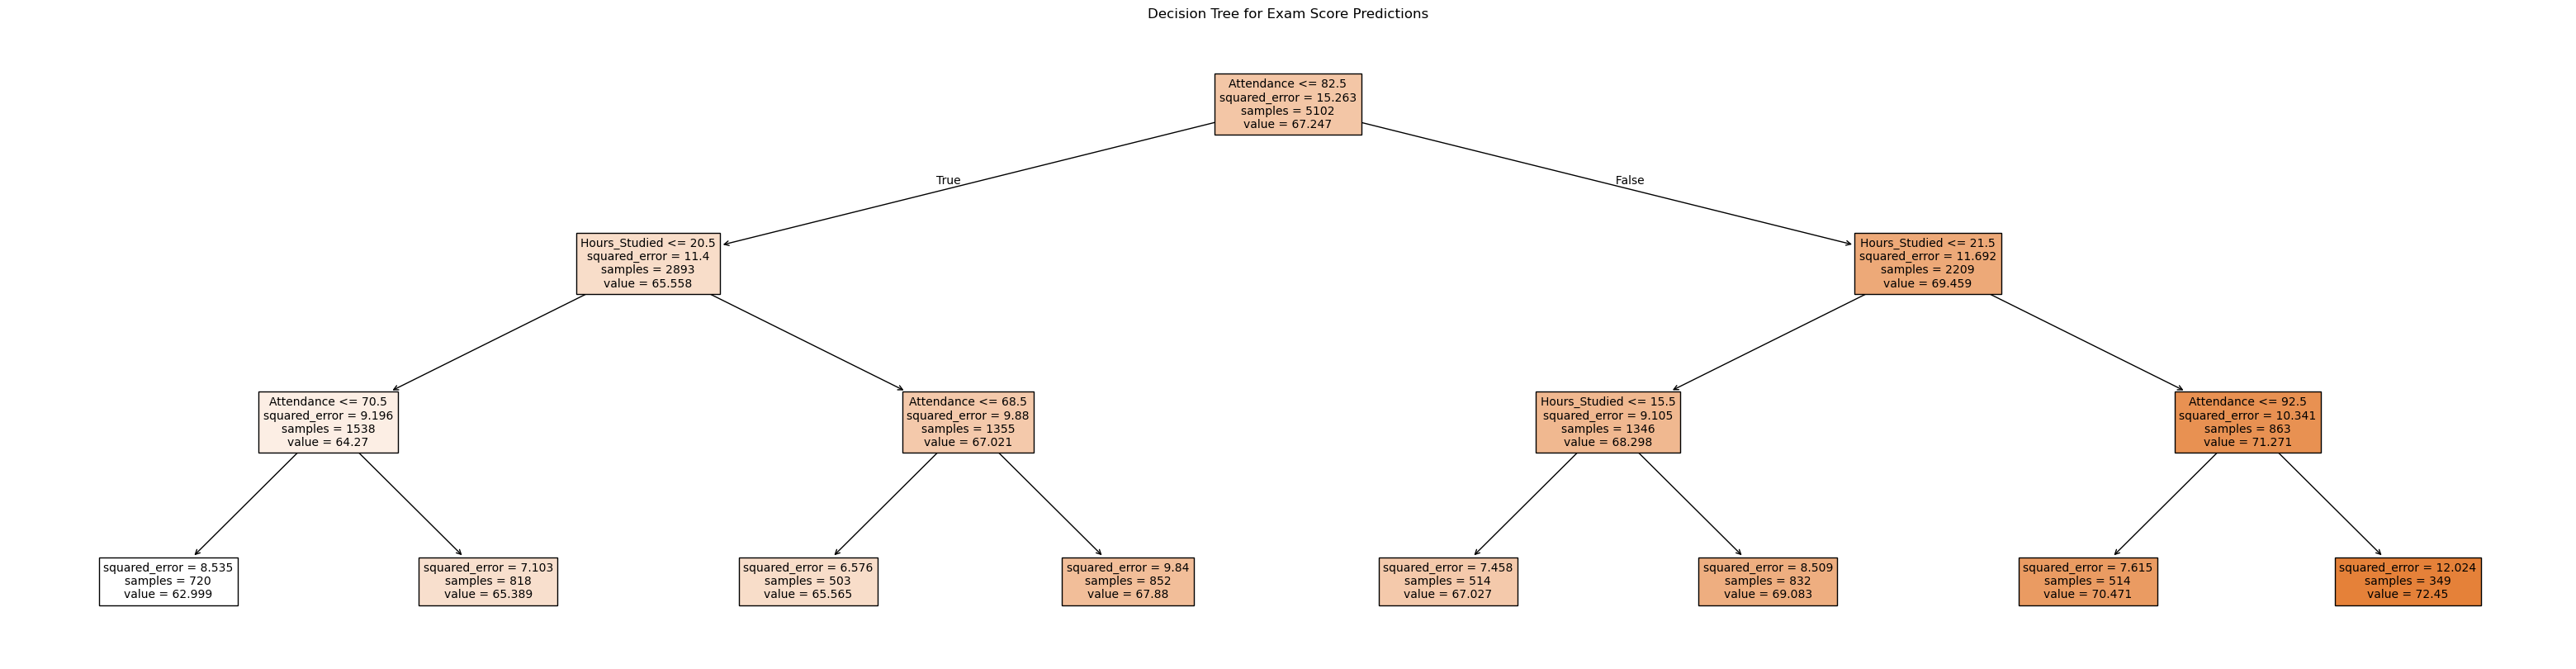

In [88]:
# Use clean df and X, y from earlier model

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit decision tree model
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Look at the important features
importance = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top Features Leading to High Scores")
print(importance.head(10))

# Plot and visualize tree
plt.figure(figsize=(40, 10))
plot_tree(dt_model, feature_names=X.columns, filled=True, fontsize=10)
plt.title("Decision Tree for Exam Score Predictions")
plt.show()

In [89]:
# Get model score
dt_test_score = dt_model.score(X_test, y_test)
print(f"{dt_test_score:.4f}")

0.4594


The testing accuracy is not that high, so we are going to try a random forest regressor model to make multiple decision trees for a more robust and accurate model.

## Random Forest Regressor

An ensemble of lots of decision trees is more robust to outliers and can capture non-linear relationships.

Training R^2: 0.7620
Testing R^2: 0.6367


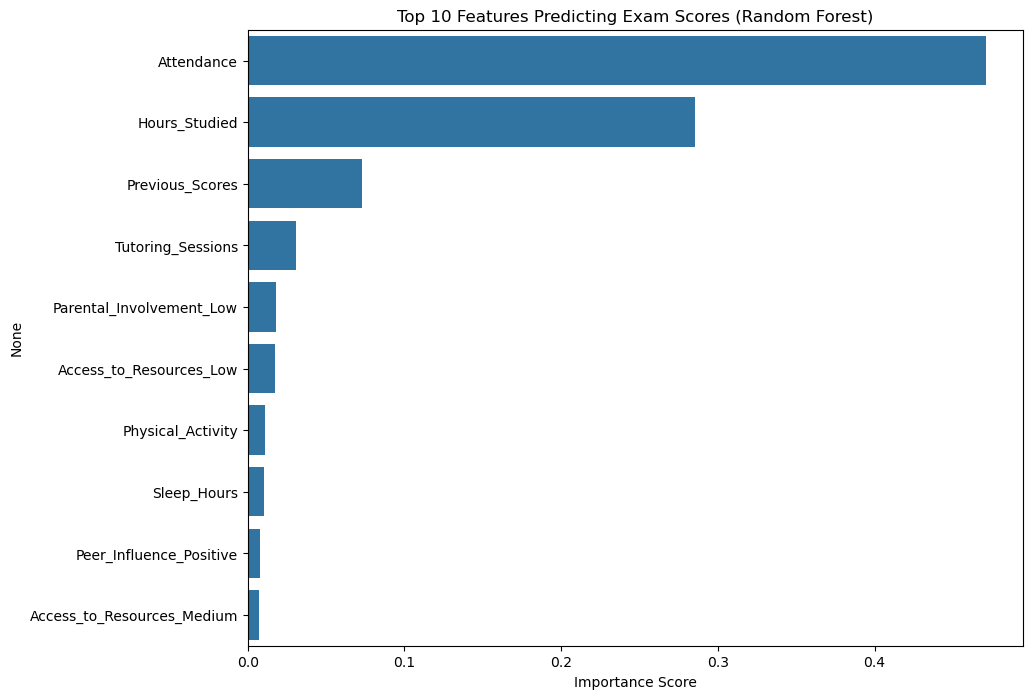

In [90]:
# Use clean df and X, y from earlier model
# Use the same train and test splits from earlier

# Fit random forest model, use 100 trees
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
rf_model.fit(X_train, y_train)

# Look at performance/accuracy (score gives R^2)
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)
print(f"Training R^2: {train_score:.4f}")
print(f"Testing R^2: {test_score:.4f}")

# Look at important features and plot
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.head(10), y=importances.head(10).index)
plt.title("Top 10 Features Predicting Exam Scores (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

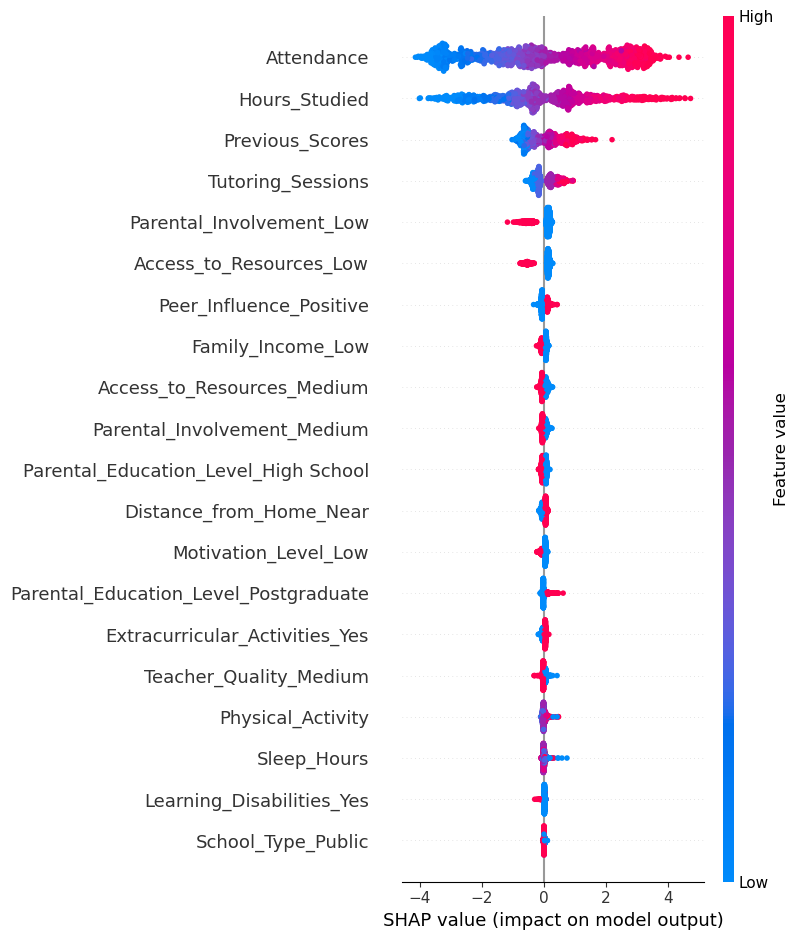

In [91]:
# Look at SHAP to see how much each feature pushed the exam score up or down for a student
# i.e., look at direction and magnitude each feature pushed the score
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

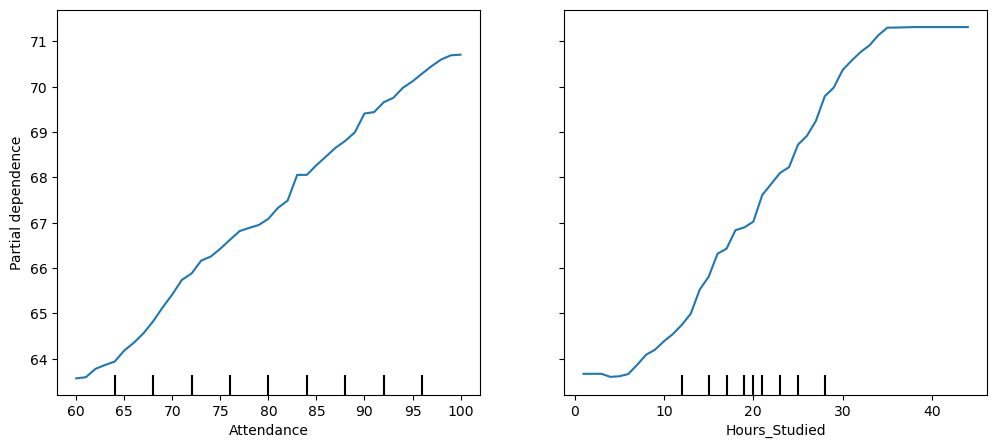

In [92]:
# Shows marginal effect of feature on the model's predicted outcome
fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(rf_model, X_train, ['Attendance', 'Hours_Studied'], ax=ax)
plt.show()

# Attendance has a strong linear relation all throughout
# Hours studied drops flat lines around 30+ hours

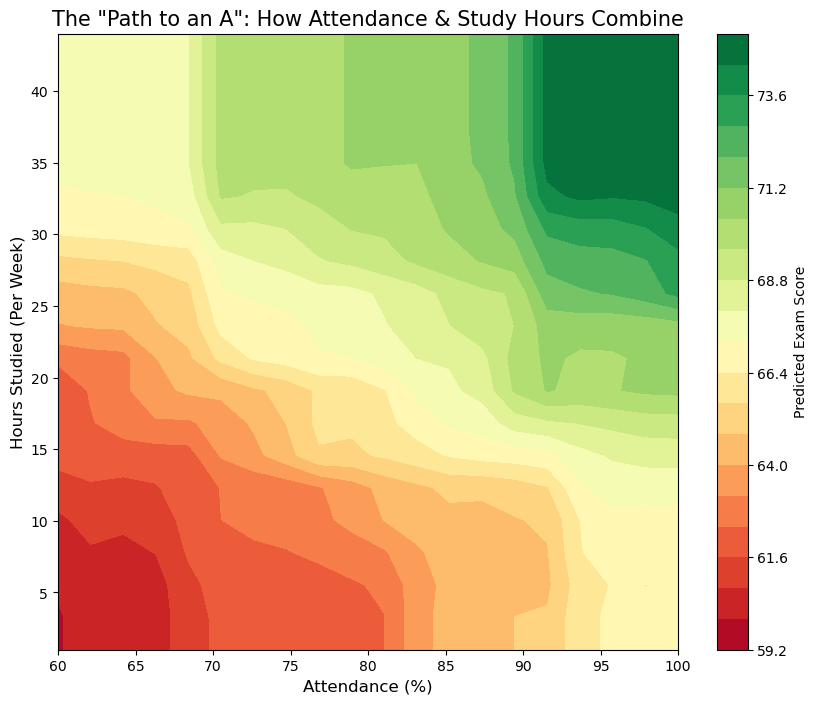

In [74]:
# Create a grid of Attendance vs Study Hours
att_range = np.linspace(stu_df['Attendance'].min(), 100, 20)
study_range = np.linspace(stu_df['Hours_Studied'].min(), stu_df['Hours_Studied'].max(), 20)
A, S = np.meshgrid(att_range, study_range)

# Create a dummy DataFrame to feed the model (setting other features to average/mode)
dummy_X = pd.DataFrame(0, index=range(400), columns=X.columns)
# (Fill dummy_X with median values from your real X_train here)
dummy_X['Attendance'] = A.ravel()
dummy_X['Hours_Studied'] = S.ravel()

# Predict scores across the grid
Z = rf_model.predict(dummy_X).reshape(20, 20)

plt.figure(figsize=(10, 8))
plt.contourf(A, S, Z, cmap='RdYlGn', levels=20)
plt.colorbar(label='Predicted Exam Score')
plt.xlabel('Attendance (%)', fontsize=12)
plt.ylabel('Hours Studied (Per Week)', fontsize=12)
plt.title('The "Path to an A": How Attendance & Study Hours Combine', fontsize=15)
plt.show()

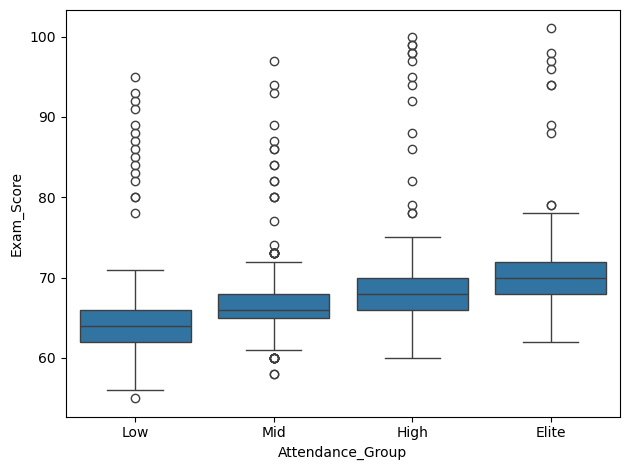

In [79]:
# Binning attendance into 4 groups for clarity
stu_df['Attendance_Group'] = pd.qcut(stu_df['Attendance'], 4, labels=['Low', 'Mid', 'High', 'Elite'])
sns.boxplot(data=stu_df, x='Attendance_Group', y='Exam_Score')
ax2.set_title('Impact of Attendance', fontsize=14)

plt.tight_layout()
plt.show()

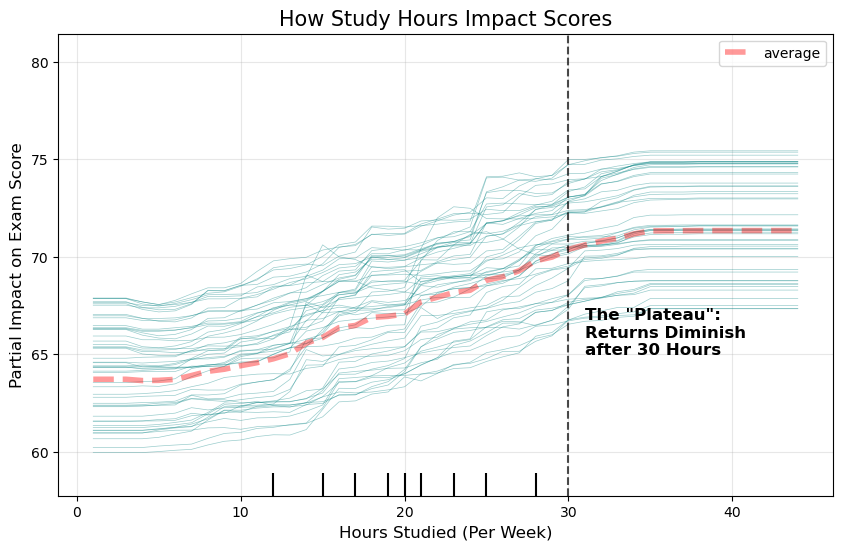

In [101]:
# 1. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# kind='both' shows the "average" (PDP) and "individual" (ICE) lines
display = PartialDependenceDisplay.from_estimator(
    rf_model, 
    X_train, 
    features=['Hours_Studied'], 
    kind='both', 
    subsample=50, # Show 50 individual student "paths"
    ax=ax,
    line_kw={"color": "teal", "alpha": 0.4}, # Individual lines (faint)
    pd_line_kw={"color": "red", "linewidth": 4} # The Average/PDP (bold)
)

# 2. Add a "Threshold" indicator
plt.axvline(x=30, color='black', linestyle='--', alpha=0.7)
plt.text(31, 65, 'The "Plateau":\nReturns Diminish\nafter 30 Hours', 
         fontsize=12, fontweight='bold', color='black')

plt.title('How Study Hours Impact Scores', fontsize=15)
plt.xlabel('Hours Studied (Per Week)', fontsize=12)
plt.ylabel('Partial Impact on Exam Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

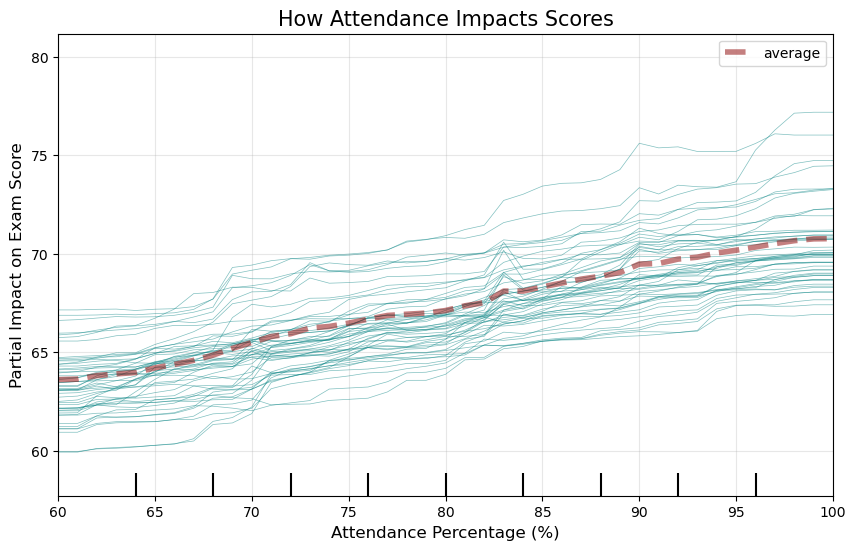

In [100]:
# 1. Create the plot for Attendance
fig, ax = plt.subplots(figsize=(10, 6))

# kind='both' shows the average (Red) and individual student paths (Teal)
display = PartialDependenceDisplay.from_estimator(
    rf_model, 
    X_train, 
    features=['Attendance'], 
    kind='both', 
    subsample=50, 
    ax=ax,
    line_kw={"color": "teal", "alpha": 0.5}, 
    pd_line_kw={"color": "darkred", "linewidth": 4} 
)

plt.xlim(60, 100)
plt.title('How Attendance Impacts Scores', fontsize=15)
plt.xlabel('Attendance Percentage (%)', fontsize=12)
plt.ylabel('Partial Impact on Exam Score', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Lasso / Ridge Regression

Lasso will perform feature selection, eliminating features that are highly correlated.

In [72]:
# Use clean df and X, y from earlier model

# Scale the features
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Fit Lasso reg model
lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_train, y_train)

# Fit Ridge reg model
ridge_model = Ridge(alpha=0.5)
ridge_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Lasso_Coef': lasso_model.coef_,
    'Ridge_Coef': ridge_model.coef_
}).sort_values(by='Lasso_Coef', ascending=False)

print(coef_df)

                                  Feature  Lasso_Coef  Ridge_Coef
2                              Attendance    1.768759    2.294595
1                           Hours_Studied    1.250356    1.770382
4                         Previous_Scores    0.170229    0.698485
5                       Tutoring_Sessions    0.094125    0.595634
0                                   const    0.000000    0.000000
16                   Family_Income_Medium    0.000000   -0.304309
26                Distance_from_Home_Near    0.000000    0.412952
25            Distance_from_Home_Moderate   -0.000000    0.140197
24  Parental_Education_Level_Postgraduate    0.000000    0.208892
23   Parental_Education_Level_High School   -0.000000   -0.238067
22              Learning_Disabilities_Yes   -0.000000   -0.266531
21                Peer_Influence_Positive    0.000000    0.497134
20                 Peer_Influence_Neutral   -0.000000    0.274095
19                     School_Type_Public   -0.000000    0.022525
18        